# Missing Data Analysis and Imputation on ELSS Data

In this notebook, we perform missing data inspection, visualization, and imputation for the ELSS dataset.

We will generate a cleaned dataset `cleaned_elss.csv` that we will be using in other analysis methods.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data
We import the dataset, parse dates, convert numeric fields, and prepare it for missing data analysis.

In [12]:
# Load dataset (replace filename)
df = pd.read_csv("final_data.csv", dtype=str)

# Parse Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y', errors='coerce')

# Convert numeric columns
for col in ['Net Asset Value','Repurchase Price','Sale Price']:
    df[col] = df[col].str.replace(',', '', regex=False).astype(float)

# Rename NAV
df.rename(columns={'Net Asset Value': 'NAV'}, inplace=True)

df = df.sort_values(['Scheme Code','Date'])
df.head()
df.describe()

,NAV,Repurchase Price,Sale Price,Date
count,319355.000000,47407.000000,47407.000000,319355
mean,78.204625,24.235111,24.369286,2021-07-10 08:01:36.133769728
min,0.000000,0.000000,0.000000,2006-04-03 00:00:00
25%,20.350000,13.664900,13.760000,2020-12-11 00:00:00
50%,31.358900,18.410000,18.535000,2022-08-08 00:00:00
75%,63.560000,29.650000,29.760000,2024-04-12 00:00:00
max,1724.475200,83.361600,84.203600,2025-11-28 00:00:00
std,162.170350,15.371636,15.416590,NaN


## 2. Missing Data Summary
We compute the total number of missing values per column.

Here we can see that `ISIN Div Reinvestment` has a lot of mising columns, while `Repurchase Price`, `ISIN Div Payout/ISIN Growth` and `Sale Price` have much lower number of misssing data.

In [13]:
missing_per_column = df.isnull().sum()
missing_per_column

Scheme Code                         0
Scheme Name                         0
ISIN Div Payout/ISIN Growth     58402
ISIN Div Reinvestment          195810
NAV                                 0
Repurchase Price               271948
Sale Price                     271948
Date                                0
dtype: int64

## 3. Missing Data Percentage
We calculate missing values as a percentage of the dataset to see what we are working with.

We can see that over 64% of `ISIN Div Reinvestment` is missing.

In [14]:
missing_percent = (df.isnull().mean() * 100).round(2)
missing_percent

Scheme Code                     0.00
Scheme Name                     0.00
ISIN Div Payout/ISIN Growth    18.29
ISIN Div Reinvestment          61.31
NAV                             0.00
Repurchase Price               85.16
Sale Price                     85.16
Date                            0.00
dtype: float64

The dataset includes two ISIN fields corresponding to different plan options of the mutual fund (Growth/Dividend Payout and Dividend Reinvestment). 
**Because our analysis focuses on NAV-based performance of each scheme over time**, and the dataset already contains NAV series per record, the ISIN fields are used only for uniquely identifying scheme variants and do not directly influence the numerical analysis. Hence, we will be removing that column from our analysis later on.

For

## 5. Missing Data Heatmap
Visual representation of missing values across numeric columns.

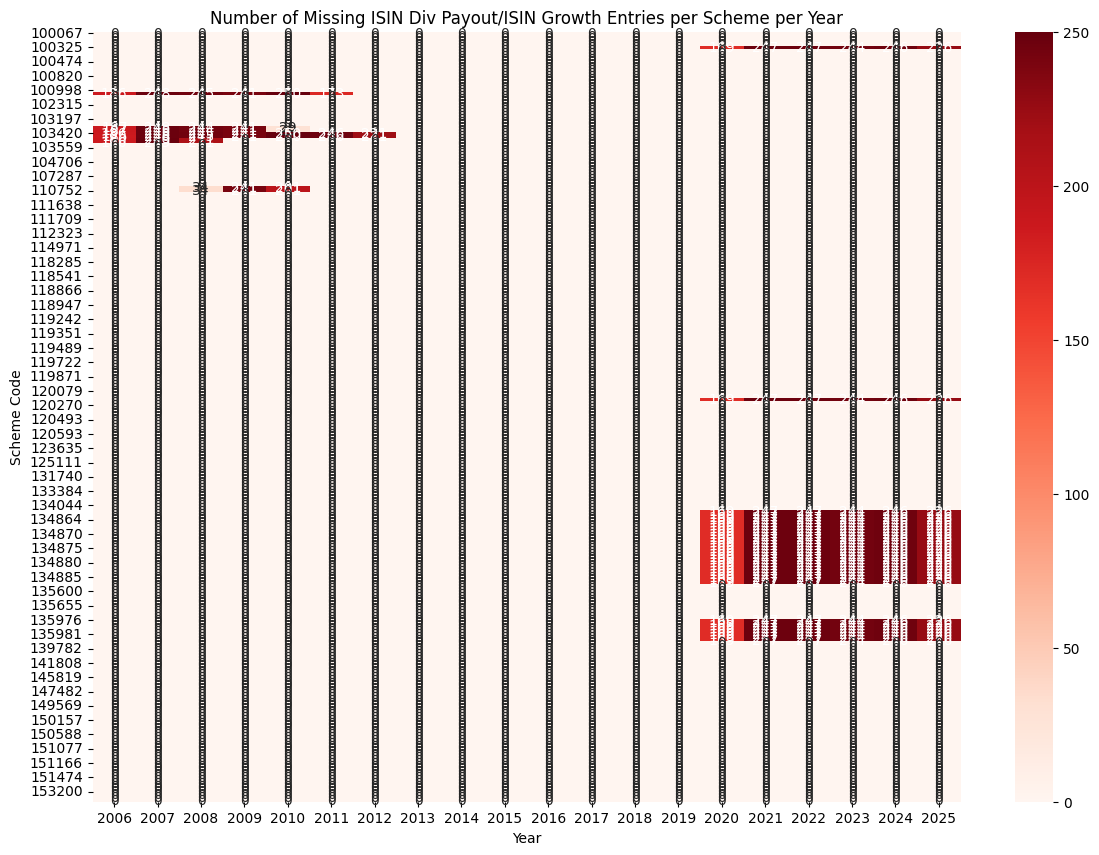

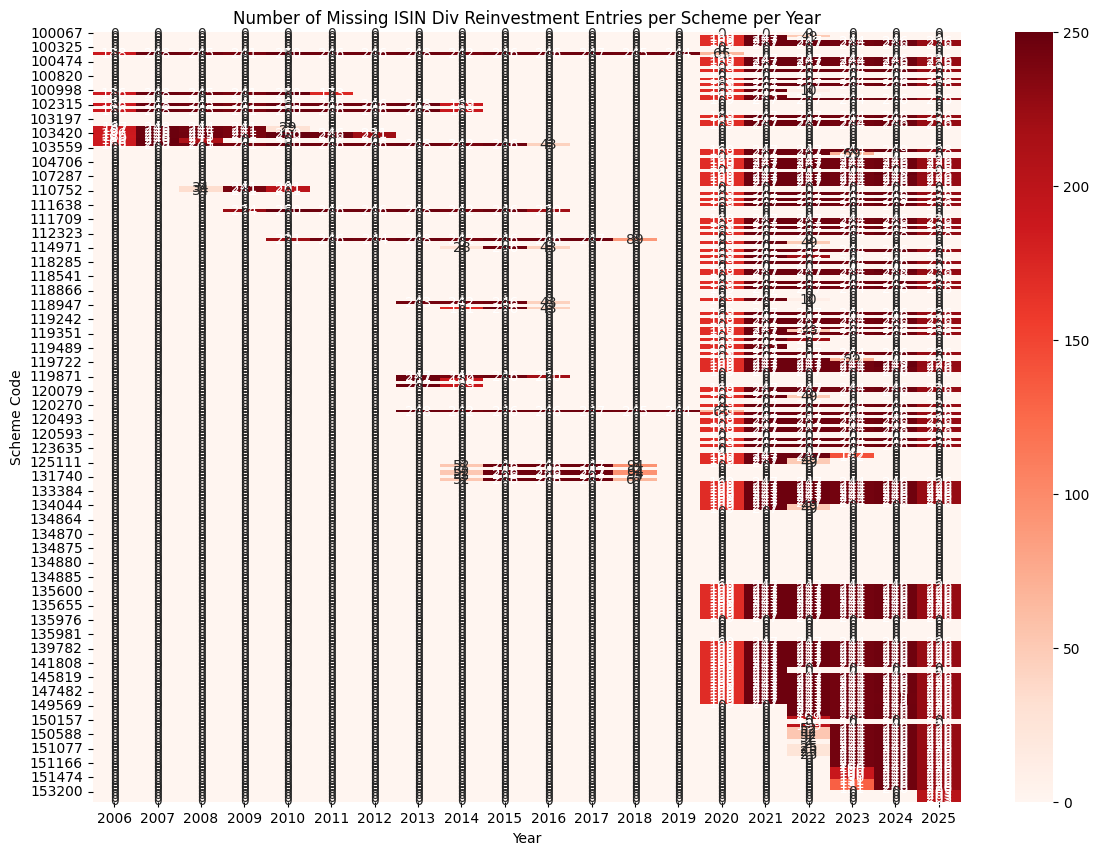

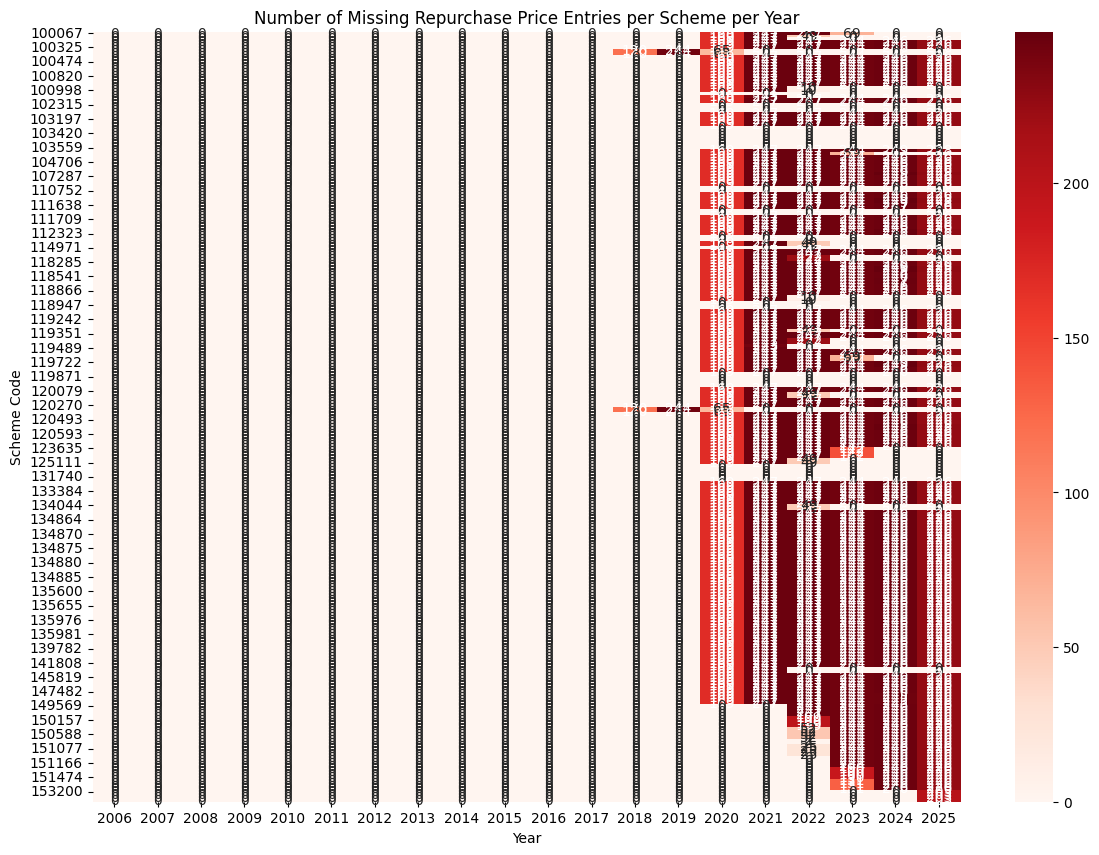

In [15]:
df_year = df.copy()
df_year['Year'] = df_year['Date'].dt.year
fig_size = (14,10) 


df_year['ISIN_growth_missing'] = df_year['ISIN Div Payout/ISIN Growth'].isnull().astype(int)
missing_counts = df_year.pivot_table(
    index="Scheme Code",
    columns="Year",
    values="ISIN_growth_missing",
    aggfunc="sum",
    fill_value=0
)
plt.figure(figsize=fig_size)
sns.heatmap(missing_counts, cmap="Reds", annot=True, fmt='d')
plt.title("Number of Missing ISIN Div Payout/ISIN Growth Entries per Scheme per Year")
plt.xlabel("Year")
plt.ylabel("Scheme Code")
plt.show()




df_year['Reinvestment_missing'] = df_year['ISIN Div Reinvestment'].isnull().astype(int)
missing_counts = df_year.pivot_table(
    index="Scheme Code",
    columns="Year",
    values="Reinvestment_missing",
    aggfunc="sum",
    fill_value=0
)
plt.figure(figsize=fig_size)
sns.heatmap(missing_counts, cmap="Reds", annot=True, fmt='d')
plt.title("Number of Missing ISIN Div Reinvestment Entries per Scheme per Year")
plt.xlabel("Year")
plt.ylabel("Scheme Code")
plt.show()


df_year['Rep_missing'] = df_year['Repurchase Price'].isnull().astype(int)
missing_counts = df_year.pivot_table(
    index="Scheme Code",
    columns="Year",
    values="Rep_missing",
    aggfunc="sum",
    fill_value=0
)
plt.figure(figsize=fig_size)
sns.heatmap(missing_counts, cmap="Reds", annot=True, fmt='d')
plt.title("Number of Missing Repurchase Price Entries per Scheme per Year")
plt.xlabel("Year")
plt.ylabel("Scheme Code")
plt.show()

### Explanation
Repurchase Price and Sale Price exhibited structural missingness after 2020 due to AMFI’s change in reporting format for Direct Plans. Because these fields are redundant with NAV and not required for return or volatility calculations, we excluded them from further analysis and relied solely on NAV, which is complete across all years and schemes

## 6. Imputation Strategy

### **NAV**
- NAV has **no missing values**.
- **No imputation required.**
- Used directly for all performance calculations (returns, CAGR, volatility, drawdowns).

---

### **Repurchase Price & Sale Price**
- Missing values: **more than 85%**.
- Missingness increases significantly **after 2020** due to AMFI reporting changes.
- Missingness is **structural**, not random.
- Repurchase Price and Sale Price closely track NAV and provide no additional analytical value.

**Recommendation:**
- Treat as **non-essential**.
- **Drop both columns** for statistical, multivariate, and modeling analysis.
- Retain only NAV for all performance-related work.

---

### **ISIN Div Payout / ISIN Growth**
- Contains the **ISIN identifier** for Growth or Dividend Payout plan variants.
- ISINs are **categorical identifiers**, not numeric variables.
- Missing values reflect unavailable plan options, not data quality issues.

**Recommendation:**
- **Do not impute.**
- Keep only as **metadata**, not for analysis.
- Exclude from EDA, correlations, and modeling.

---

### **ISIN Div Reinvestment**
- Contains the ISIN for the **Dividend Reinvestment** plan variant.
- Often empty because many schemes do not offer a Reinvestment option or AMFI does not publish it.
- Also a **categorical identifier**, unrelated to NAV-level performance.

**Recommendation:**
- **No imputation needed.**
- Retain as metadata only.
- Exclude from quantitative analysis entirely.


In [16]:
cols_to_drop = ['Repurchase Price', 'Sale Price']

df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# --- Optional: Ensure ISIN columns stay as metadata (string dtype) ---
isin_cols = ['ISIN Div Payout/ISIN Growth', 'ISIN Div Reinvestment']
for col in isin_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('string')

# --- Optional: Remove rows with missing NAV (should be none) ---
df_clean = df_clean[df_clean['NAV'].notna()]

# --- Final check ---
print("Final columns:", df_clean.columns.tolist())
print(df_clean.head())


Final columns: ['Scheme Code', 'Scheme Name', 'ISIN Div Payout/ISIN Growth', 'ISIN Div Reinvestment', 'NAV', 'Date']
      Scheme Code                                     Scheme Name  \
57535      100067  Aditya Birla Sun Life Tax Plan -Regular - IDCW   
57536      100067  Aditya Birla Sun Life Tax Plan -Regular - IDCW   
57537      100067  Aditya Birla Sun Life Tax Plan -Regular - IDCW   
57538      100067  Aditya Birla Sun Life Tax Plan -Regular - IDCW   
57539      100067  Aditya Birla Sun Life Tax Plan -Regular - IDCW   

      ISIN Div Payout/ISIN Growth ISIN Div Reinvestment    NAV       Date  
57535                INF209K01330          INF209K01CM8  70.30 2020-05-04  
57536                INF209K01330          INF209K01CM8  69.73 2020-05-05  
57537                INF209K01330          INF209K01CM8  70.27 2020-05-06  
57538                INF209K01330          INF209K01CM8  69.70 2020-05-07  
57539                INF209K01330          INF209K01CM8  69.73 2020-05-08  


## 8. Save Cleaned Dataset
We save only the cleaned fields for downstream EDA.

In [17]:
df_clean.to_csv("cleaned_elss.csv", index=False)
print("Saved cleaned dataset → cleaned_elss.csv")

Saved cleaned dataset → cleaned_elss.csv
